# Song Popularity Prediction

In this notebook we will do some data analysis to see some underlying pattern present in the spotify record dataset provided by Kaggle<br><br>

**1. Importing Libraries:**

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, pearsonr

**2. Loading the dataset:**

In [2]:
df = pd.read_csv('../data/raw/spotify_tracks.csv')
df.sample(5)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
7081,7081,58oZjQwET9oX37wSXlntGX,Balsam Range,Last Train To Kitty Hawk,Caney Fork River,30,181920,False,0.649,0.743,...,-4.961,1,0.0339,0.47000,0.000000,0.2670,0.876,127.046,4,bluegrass
9130,9130,5h7e9eHY6RnP617D9zzzKb,Gerson Rufino,Sobrevivi,Vai Passar,51,332933,False,0.526,0.555,...,-4.789,1,0.0262,0.03700,0.000000,0.1400,0.223,136.008,4,brazil
109094,109094,5s76Adm7BH1gbWsVhDKrnf,Cosmic Gate;Diana Miro,Black Hole House Music 10-22,Hear Me Out - Extended Mix,0,445406,False,0.602,0.916,...,-5.910,0,0.0413,0.00277,0.560000,0.0864,0.036,122.997,4,techno
19990,19990,6Lo21kYgNY0ASua2c4aQvN,BEIST,Dans som en idiot,Råne-Ræser,42,194170,False,0.715,0.649,...,-8.077,0,0.0286,0.63900,0.000339,0.4910,0.722,105.058,4,country
13491,13491,3HkqYvL5Ap3gc6mbozpn5r,Bad Boy Bill;Alyssa Palmer,The Album,Falling Anthem,10,270013,False,0.818,0.709,...,-5.417,1,0.0358,0.00155,0.042400,0.0868,0.723,127.976,4,chicago-house


**3. Exploratory Data Analysis:**<br> 
* Basic analysis(without graphs)

In [3]:
df.shape

(114000, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


* Since the target column -'Popularity' have values ranging from 0 to 100 seeing value count will not help much .<br>
Hence we will plot the distribution by binning the values in bin of 5 (0-5, 5-10 ...)

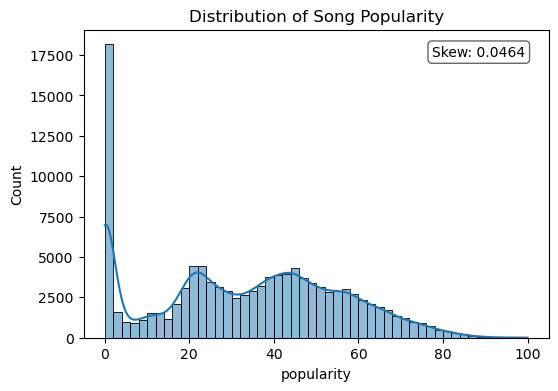

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df['popularity'], bins=50, kde=True)
plt.title("Distribution of Song Popularity")
plt.text(0.95, 0.95, f"Skew: {df['popularity'].skew():.4f}", transform=plt.gca().transAxes, ha='right', va='top',bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))
plt.show()

 * Before doing further analysis, we will drop some features that wil surely not affect the target columns

In [7]:
df.drop(columns=['Unnamed: 0','track_id', 'track_name'], inplace=True)
df.columns

Index(['artists', 'album_name', 'popularity', 'duration_ms', 'explicit',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'time_signature', 'track_genre'],
      dtype='object')

  
**Univariate Analysis**

* Now doing the analysis using graphs 

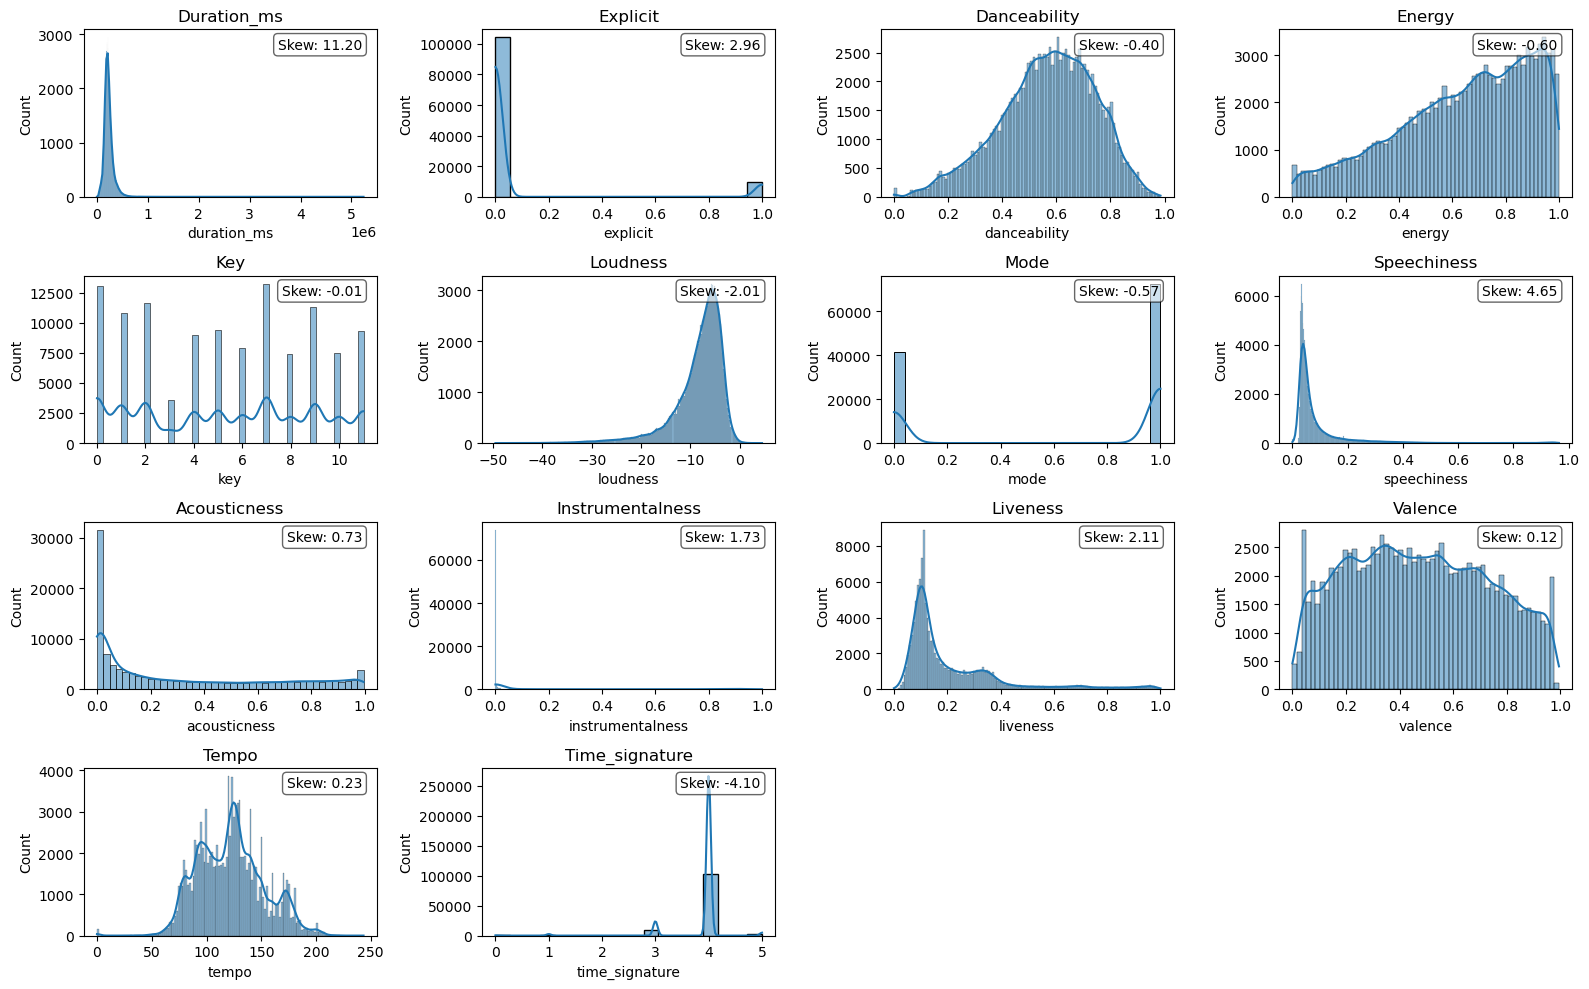

In [11]:
features = ['duration_ms', 'explicit',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'time_signature']
plt.figure(figsize=(16, 10))

for i, col in enumerate(features, 1):
    plt.subplot(4, 4, i)
    
    sns.histplot(df[col], kde=True)
    
    skew_val = df[col].skew()
    plt.title(col.capitalize())
    plt.text(0.95, 0.95, f"Skew: {skew_val:.2f}", transform=plt.gca().transAxes, ha='right', va='top', bbox=dict(boxstyle="round", facecolor="white", alpha=0.6))

    
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


Here the distribution of all numerical columns is graphed and the skewness is also mentioned. Now according to this each of them will have proper transformation.<br>
Also from the graph we can infer that <br>
* **mode** is a binary valued column which can be treated as **categorical column** <br>
* **key** have only values from 0 to 10 and haence can be treated as **categorical column**

Now for the categorical we will see how many specific categories are there 

In [12]:
cols = ['artists', 'album_name', 'popularity','explicit', 'time_signature', 'track_genre']

for col in cols:
    print(f"\nNumber of categories in {col}: {df[col].nunique()}")


Number of categories in artists: 31437

Number of categories in album_name: 46589

Number of categories in popularity: 101

Number of categories in explicit: 2

Number of categories in time_signature: 5

Number of categories in track_genre: 114


**Correlation Analysis**

Now we will see the correlation between each and every features.<br>
First we will use heatmap

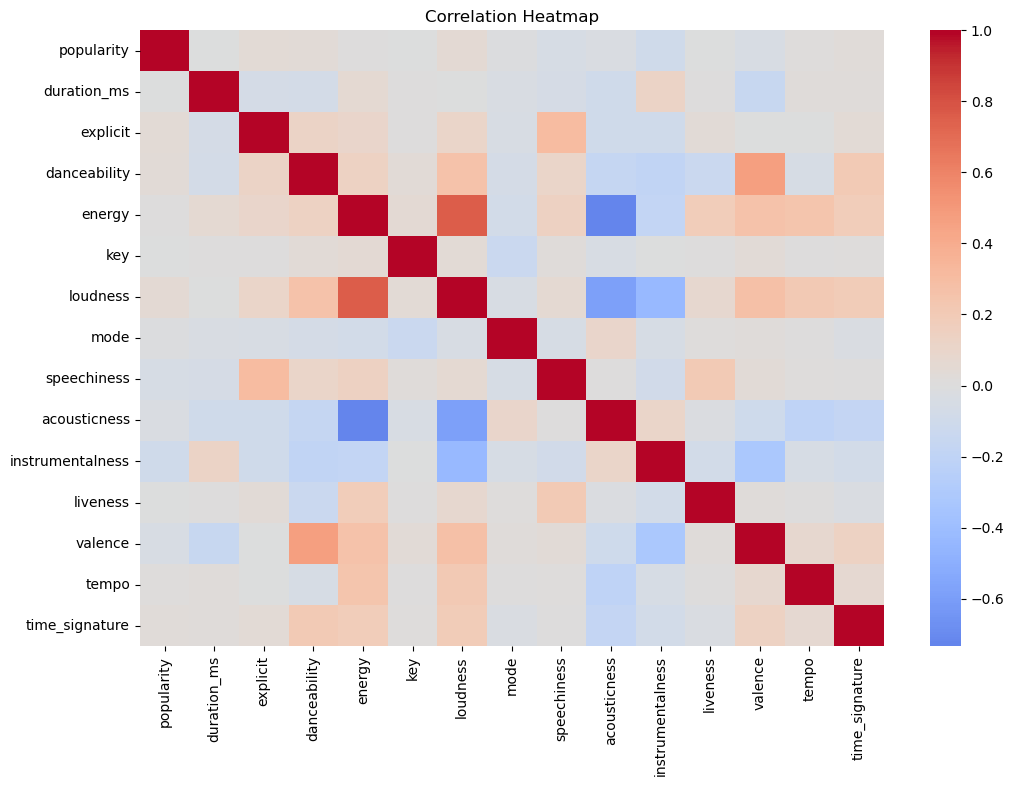

In [13]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
corr['popularity'].sort_values(ascending=False)

popularity          1.000000
loudness            0.050423
explicit            0.044082
danceability        0.035448
time_signature      0.031073
tempo               0.013205
energy              0.001056
key                -0.003853
liveness           -0.005387
duration_ms        -0.007101
mode               -0.013931
acousticness       -0.025472
valence            -0.040534
speechiness        -0.044927
instrumentalness   -0.095139
Name: popularity, dtype: float64

Here from the heatmap and correlation values we find that the columns that have correlation with **"popularity"**:<br>
* Positive Correlations: <br>
-- loudness <br>
-- explicit <br>
-- danceability  <br>
-- time_signature  <br><br>

* Negative Correlations: <br>
-- instrumentalness  <br>
-- speechiness <br>
-- valence <br>
-- acousticness <br>

Some features show **strong correlations** with each other.
* Energy vs Loudness -- strong positive<br>
* Danceability vs Valence -- moderate positive<br>
* Energy vs Acousticness -- strong negative<br>
* Loudness vs Acousticness -- negative

Instrumentalness shows negative correlation with:
* Popularity<br>
* Valence<br>
* Loudness

Some features have almost no impact on other variables.
* Key
* Mode
* Tempo
* Time signature

Now we will use sprearman correlation to find the monotonic correlations

In [35]:
print("Spearman Correlation with Popularity:")
for col in df.columns:
    corr,_ = spearmanr(df[col], df['popularity'])
    print(col, round(corr,3))

Spearman Correlation with Popularity:
artists nan
album_name nan
popularity 1.0
duration_ms 0.028
explicit 0.04
danceability 0.027
energy -0.024
key -0.003
loudness 0.035
mode -0.015
speechiness -0.068
acousticness 0.008
instrumentalness -0.078
liveness -0.008
valence -0.042
tempo 0.017
time_signature 0.036
track_genre 0.034
popularity_class 0.574


Here from the spearman correlation values we find that the columns that have non-linear correlation with **"popularity"**:<br>
* Positive Correlations: <br>
-- time_signature <br>
-- loudness<br><br>

* Negative Correlations: <br>
-- instrumentalness  <br>
-- speechiness <br>
-- valence <br>

Using Pearson correlation to find the linear correlations

In [36]:
print("Pearson Correlation with Popularity:")
for col in df.columns:
    try:
        corr, _ = pearsonr(df[col], df['popularity'])
        print(col, round(corr, 3))
    except:
        continue

Pearson Correlation with Popularity:
popularity 1.0
duration_ms -0.007
explicit 0.044
danceability 0.035
energy 0.001
key -0.004
loudness 0.05
mode -0.014
speechiness -0.045
acousticness -0.025
instrumentalness -0.095
liveness -0.005
valence -0.041
tempo 0.013
time_signature 0.031


Both correlations show very similar results.<br>
**Interpretation**
* Relationships between features are mostly linear.
* There are no strong monotonic nonlinear relationships.

**Popularity Bucketing**

Now we will bucket the popularities to see the trends.<br>
We will plot the features' density based on the popularity

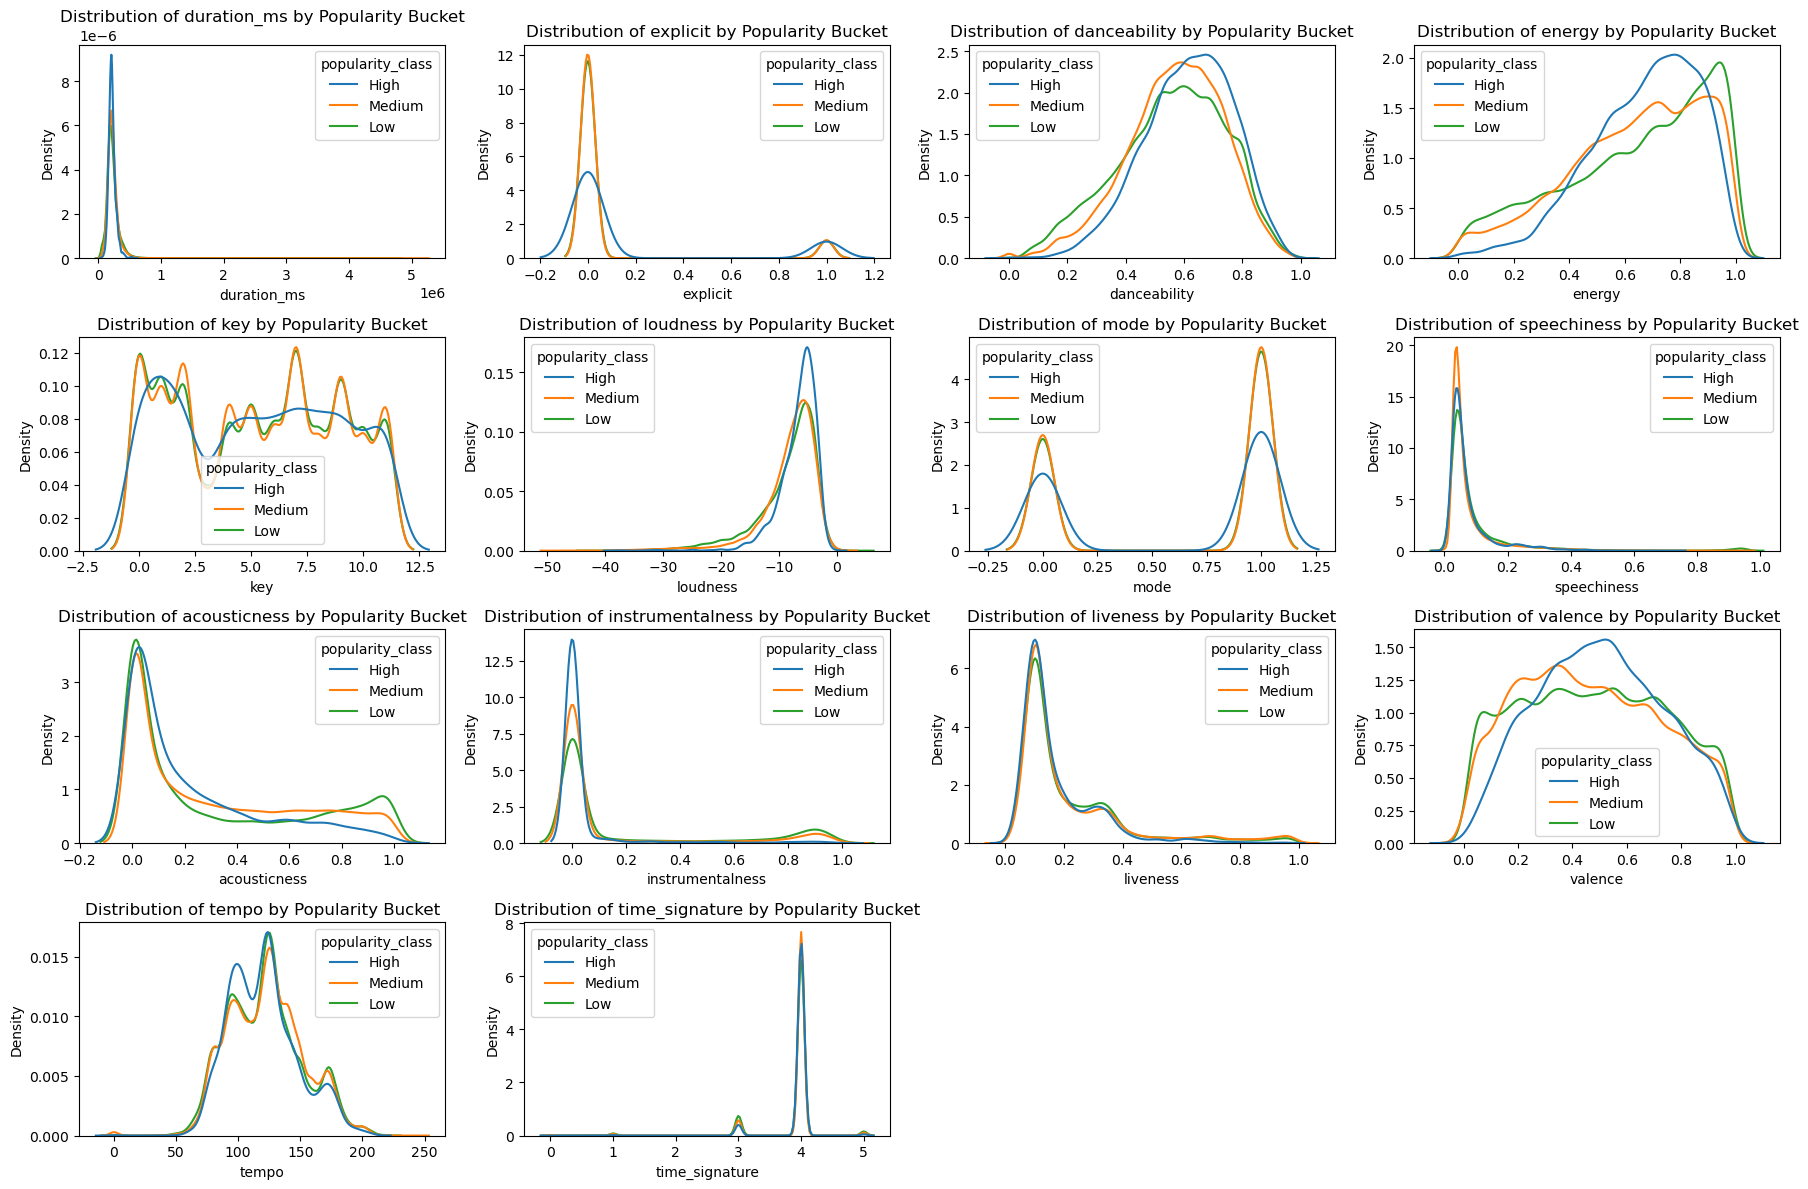

In [20]:
def popularity_bucket(x):
    if x < 30:
        return "Low"
    elif x < 70:
        return "Medium"
    else:
        return "High"

df['popularity_class'] = df['popularity'].apply(popularity_bucket)
df['popularity_class'].value_counts()


plt.figure(figsize=(18, 12))

for i, col in enumerate(features, 1):
    plt.subplot(4, 4, i)
    sns.kdeplot(data=df,x=col,hue='popularity_class',fill=False,common_norm=False)
    plt.title(f"Distribution of {col} by Popularity Bucket")

plt.tight_layout()
plt.show()

Observations :
* **danceability**: <br>
        --High popularity songs tend to cluster around **high** danceability values.<br>
        --Low popularity songs show a slightly wider spread toward **low** values.<br><br>

* **energy**: <br>
        --High popularity songs are concentrated around **moderate to high** energy levels.<br>
        --Low popularity songs include **more low-energy** tracks.<br><br>

* **loudness**: <br>
        --High popularity songs tend to cluster around **high** loudness values.<br>
        --Low popularity songs show slightly **lower** loudness levels.<br><br>

* **acousticness**: <br>
        --High popularity songs tend to have **low** acousticness values.<br>
        --Low popularity songs include more **high** acoustic tracks.<br><br>
                
* **valence**: <br>
        --High popularity songs are slightly concentrated around **medium** valence values.<br><br>


**Genre and Artist Analysis**

Now we will see the top 10 track genre for each popularity bucket

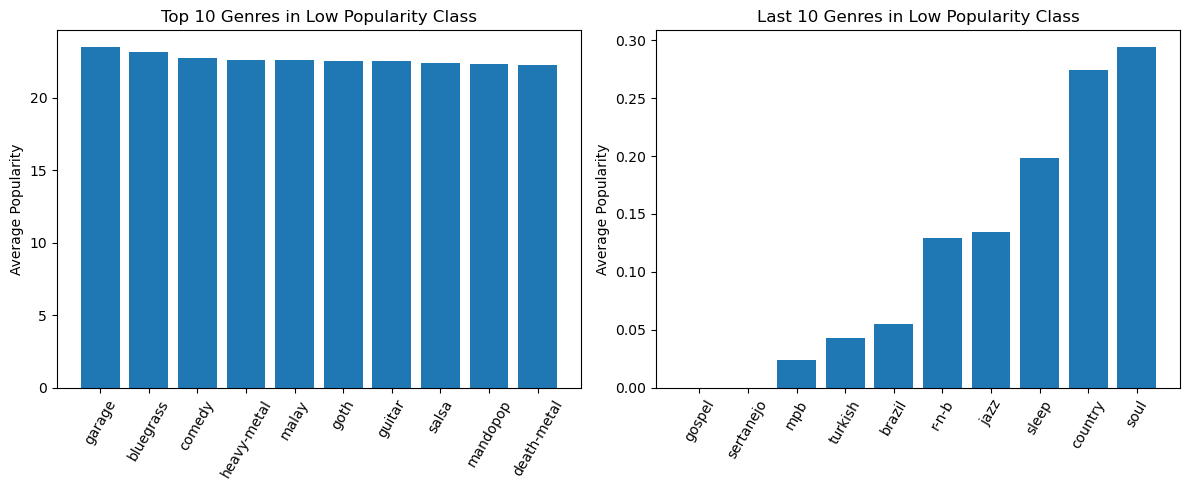

In [24]:
# Group by popularity_class and genre
genre_pop = (
    df.groupby(['popularity_class', 'track_genre'])['popularity']
      .mean()
      .reset_index()
)

for cls in df['popularity_class'].unique():

    top10 = (
        genre_pop[genre_pop['popularity_class'] == cls]
        .sort_values(by='popularity', ascending=False)
        .head(10)
    )

    last10 = (
        genre_pop[genre_pop['popularity_class'] == cls]
        .sort_values(by='popularity', ascending=True)
        .head(10)
    )

plt.figure(figsize=(12,5))

    # Top 10
plt.subplot(1, 2, 1)
plt.bar(top10['track_genre'], top10['popularity'])
plt.xticks(rotation=60)
plt.title(f"Top 10 Genres in {cls} Popularity Class")
plt.ylabel("Average Popularity")

    # Last 10
plt.subplot(1, 2, 2)
plt.bar(last10['track_genre'], last10['popularity'])
plt.xticks(rotation=60)
plt.title(f"Last 10 Genres in {cls} Popularity Class")
plt.ylabel("Average Popularity")

plt.tight_layout()
plt.show()


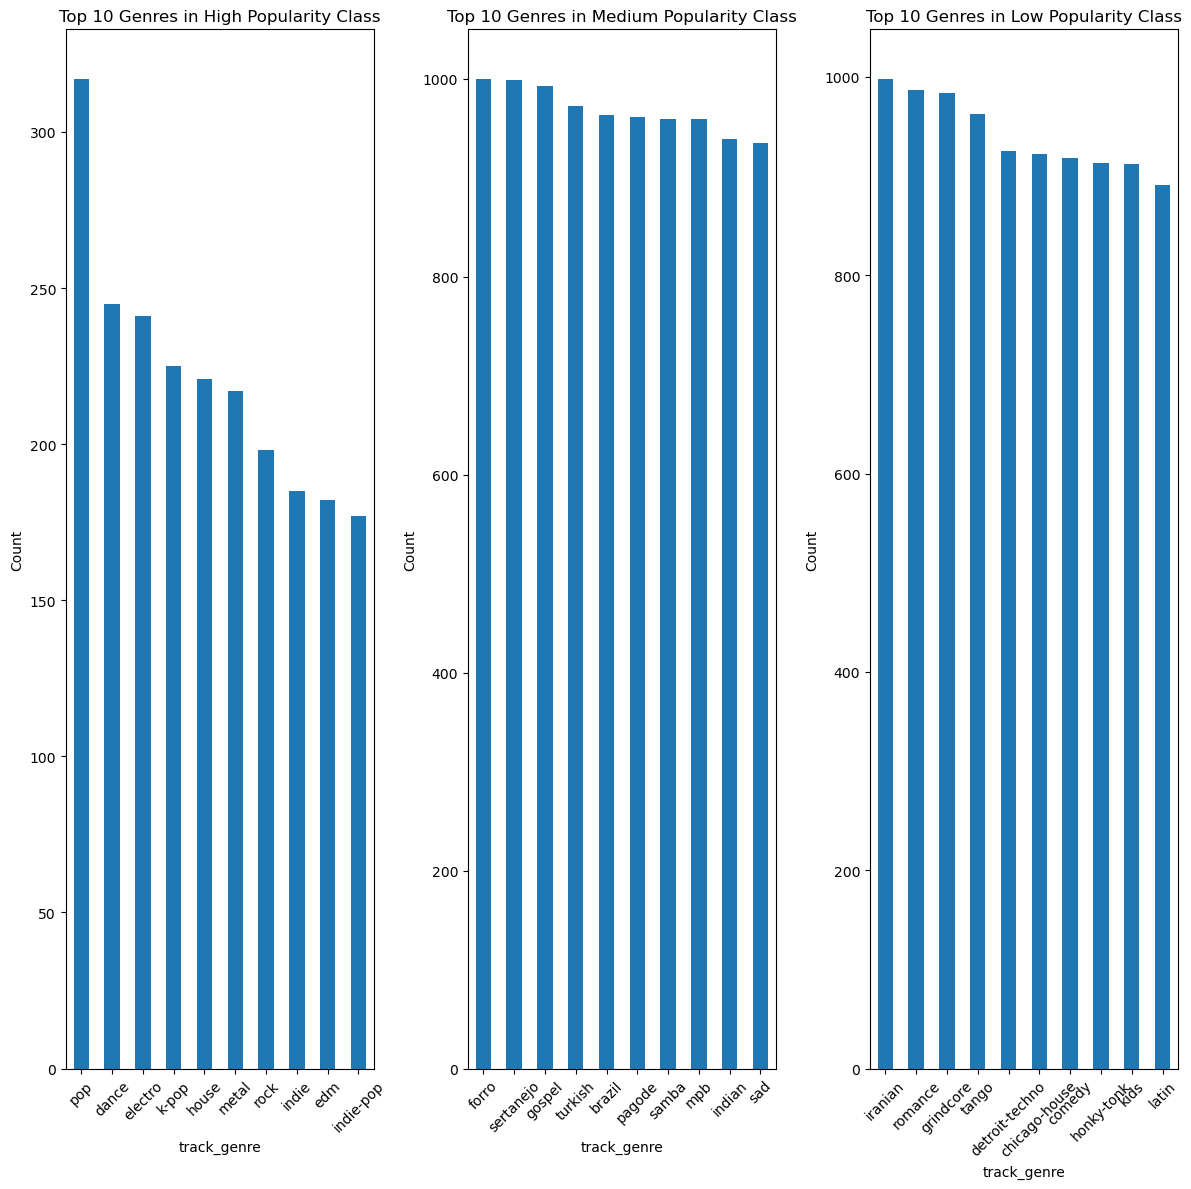

In [32]:
plt.figure(figsize=(12,12))

for i, cls in enumerate(df['popularity_class'].unique(), 1):
    
    top10 = (
        df[df['popularity_class'] == cls]['track_genre']
        .value_counts()
        .head(10)
    )
    
    plt.subplot(1, 3, i)
    top10.plot(kind='bar')
    plt.title(f"Top 10 Genres in {cls} Popularity Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [34]:
artist_var = df.groupby('artists')['popularity'].std().sort_values(ascending=False).head(10)
artist_var

artists
Justin Bieber;Ludacris        57.982756
Jordan Davis;Luke Bryan       56.568542
Cardi B;Bad Bunny;J Balvin    55.861436
Amaarae;Kali Uchis;Moliy      55.154329
Jordan Davis                  53.033009
Roy Woods;Drake               53.033009
Arz                           51.618795
Armani White                  51.097130
Selena Gomez;Gucci Mane       50.911688
Omar Apollo;Daniel Caesar     49.497475
Name: popularity, dtype: float64